# 04 Intrahost Variant Calling

**Methods mapping:** intrahost variant calling.

This notebook starts from the full raw LoFreq iSNV CSV. The manuscript filters are applied here: retained samples only, G-gene coordinates, SNVs rather than indels, and 3% <= allele frequency < 97%.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('04_intrahost_variant_calling', ROOT)
INPUTS = {
    "lofreq_raw_calls": ROOT / "data/input/isnv/lofreq_raw_calls.csv",
    "metadata": ROOT / "data/metadata/meta_v6_with_season_clade.csv",
    "AU_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1037681_extracted_4652-5617.fasta",
    "US_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1130896_extracted_4652-5617.fasta",
}
OUTPUTS = {
    "filtered_g_snv_calls": DATA_DIR / "lofreq_g_snv_calls_3to97.csv",
    "per_sample_counts": DATA_DIR / "per_sample_g_isnv_counts.csv",
    "site_recurrence": DATA_DIR / "g_isnv_site_recurrence.csv",
    "figure_png": FIG_DIR / "Fig1CD_and_FigS1_G_iSNV_summary.png",
    "figure_pdf": FIG_DIR / "Fig1CD_and_FigS1_G_iSNV_summary.pdf",
    "figure_svg": FIG_DIR / "Fig1CD_and_FigS1_G_iSNV_summary.svg",
}


def show_paths(title, paths):
    rows = []
    for name, path in paths.items():
        path = Path(path)
        rows.append({"name": name, "relative_path": rel(path), "exists": path.exists()})
    display(Markdown(f"### {title}"))
    display(pd.DataFrame(rows))

for path in OUTPUTS.values():
    Path(path).parent.mkdir(parents=True, exist_ok=True)

show_paths("Input paths", INPUTS)
show_paths("Output paths", OUTPUTS)
DATA_DIR, FIG_DIR


### Input paths

,name,relative_path,exists
0,lofreq_raw_calls,data/input/isnv/lofreq_raw_calls.csv,True
1,metadata,data/metadata/meta_v6_with_season_clade.csv,True
2,AU_haplotype_fasta,data/input/haplotypes/PRJNA1037681_...,True
3,US_haplotype_fasta,data/input/haplotypes/PRJNA1130896_...,True


### Output paths

,name,relative_path,exists
0,filtered_g_snv_calls,data/processed_data/04_intrahost_variant...,True
1,per_sample_counts,data/processed_data/04_intrahost_variant...,True
2,site_recurrence,data/processed_data/04_intrahost_variant...,True
3,figure_png,results/figures/04_intrahost_varian...,True
4,figure_pdf,results/figures/04_intrahost_varian...,True
5,figure_svg,results/figures/04_intrahost_varian...,True


(PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/data/processed_data/04_intrahost_variant_calling'),
 PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/results/figures/04_intrahost_variant_calling'))

## Read Raw LoFreq Calls

The raw table below is the allowed iSNV input. I summarize it before filtering so that the later candidate table can be checked against the starting call set.


In [3]:
raw_lofreq = au.normalized_lofreq_raw(ROOT)
raw_lofreq['is_G'] = raw_lofreq['position'].between(au.G_START, au.G_END)
raw_lofreq['passes_af_window'] = raw_lofreq['AF'].between(au.ISNV_AF_MIN, au.ISNV_AF_MAX, inclusive='left')
raw_summary = raw_lofreq.groupby('project', as_index=False).agg(
    raw_rows=('SampleID', 'size'),
    samples=('SampleID', 'nunique'),
    G_region_rows=('is_G', 'sum'),
    AF_window_rows=('passes_af_window', 'sum'),
)

display(raw_summary)
display(raw_lofreq[['project', 'SampleID', 'position', 'Reference', 'Allele', 'DP', 'AF', 'is_indel', 'is_G']].head())


,project,raw_rows,samples,G_region_rows,AF_window_rows
0,PRJNA1037681,27839,37,2873,1061
1,PRJNA1130896,23600,72,2611,1274


,project,SampleID,position,Reference,Allele,DP,AF,is_indel,is_G
0,PRJNA1037681,SRR26779971,66,T,A,944,0.996822,False,False
1,PRJNA1037681,SRR26779971,67,A,G,948,0.998945,False,False
2,PRJNA1037681,SRR26779971,90,C,T,914,0.997812,False,False
3,PRJNA1037681,SRR26779971,183,C,T,678,1.000000,False,False
4,PRJNA1037681,SRR26779971,270,T,C,1372,0.008746,False,False


## Apply Manuscript Filters

The output tables are generated from the raw calls plus the retained sample table rebuilt from metadata and haplotype FASTA.


In [4]:
calls, counts, recurrence = au.intrahost_variant_calling(ROOT, DATA_DIR)

display(calls.head())
display(counts.head())
display(recurrence.head(15))


,project,project_label,SampleID,global_short_label,position,Type,Reference,Allele,Count,Coverage,AF,Frequency,mutation_right_name,is_G,is_HVR2,aa_position,variant_class,filter,qual,sb
0,PRJNA1037681,Australia,SRR26779971,AU-S01,4821,SNV,C,T,204,4012,0.050847,5.0847,C_4821_T,True,False,57,SNV,PASS,3798,0
1,PRJNA1037681,Australia,SRR26779971,AU-S01,5510,SNV,G,A,29,638,0.045455,4.5455,G_5510_A,True,True,287,SNV,PASS,424,0
2,PRJNA1037681,Australia,SRR26779971,AU-S01,5520,SNV,A,T,34,618,0.055016,5.5016,A_5520_T,True,True,290,SNV,PASS,622,0
3,PRJNA1037681,Australia,SRR26779971,AU-S01,5544,SNV,C,T,569,605,0.940496,94.0496,C_5544_T,True,True,298,SNV,PASS,20620,0
4,PRJNA1037681,Australia,SRR26779971,AU-S01,5558,SNV,G,A,580,608,0.953947,95.3947,G_5558_A,True,True,303,SNV,PASS,20810,0


,project,project_label,SampleID,global_short_label,candidate_G_iSNVs
0,PRJNA1037681,Australia,SRR26779971,AU-S01,6
1,PRJNA1037681,Australia,SRR26780187,AU-S02,5
2,PRJNA1037681,Australia,SRR26780146,AU-S03,5
3,PRJNA1037681,Australia,SRR26780067,AU-S04,7
4,PRJNA1037681,Australia,SRR26780213,AU-S05,0


,project,project_label,position,aa_position,Reference,Allele,is_HVR2,samples_with_candidate_iSNV,median_frequency_percent,min_frequency_percent,max_frequency_percent,median_depth
12,PRJNA1037681,Australia,5520,290,A,T,True,34,6.67170,3.1716,10.6090,783.0
17,PRJNA1037681,Australia,5544,298,C,T,True,34,92.35940,3.3413,95.7921,800.5
19,PRJNA1037681,Australia,5563,304,T,C,True,31,5.55160,3.6660,96.2205,763.0
10,PRJNA1037681,Australia,5510,287,G,A,True,30,5.47120,3.1902,9.1858,821.0
18,PRJNA1037681,Australia,5558,303,G,A,True,29,94.29100,89.5906,96.6292,728.0
7,PRJNA1037681,Australia,5472,274,C,T,True,8,3.91545,3.2503,5.6497,494.0
9,PRJNA1037681,Australia,5491,280,T,C,True,6,96.17640,3.4188,96.7621,560.0
4,PRJNA1037681,Australia,5448,266,A,T,True,4,96.77290,96.5217,96.9549,1599.5
8,PRJNA1037681,Australia,5486,279,G,A,True,4,3.39290,3.0246,4.4199,355.0
16,PRJNA1037681,Australia,5539,296,C,T,True,3,95.90290,95.5067,96.3265,1046.0


## Figure

The figure panels are drawn from the regenerated filtered-call and per-sample count tables.


/root/autodl-tmp/rsva-g-intrahost-haplotypes/notebooks/analysis_utils.py:1058: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


{'png': 'results/figures/04_intrahost_variant_calling/Fig1CD_and_FigS1_G_iSNV_summary.png',
 'pdf': 'results/figures/04_intrahost_variant_calling/Fig1CD_and_FigS1_G_iSNV_summary.pdf',
 'svg': 'results/figures/04_intrahost_variant_calling/Fig1CD_and_FigS1_G_iSNV_summary.svg'}

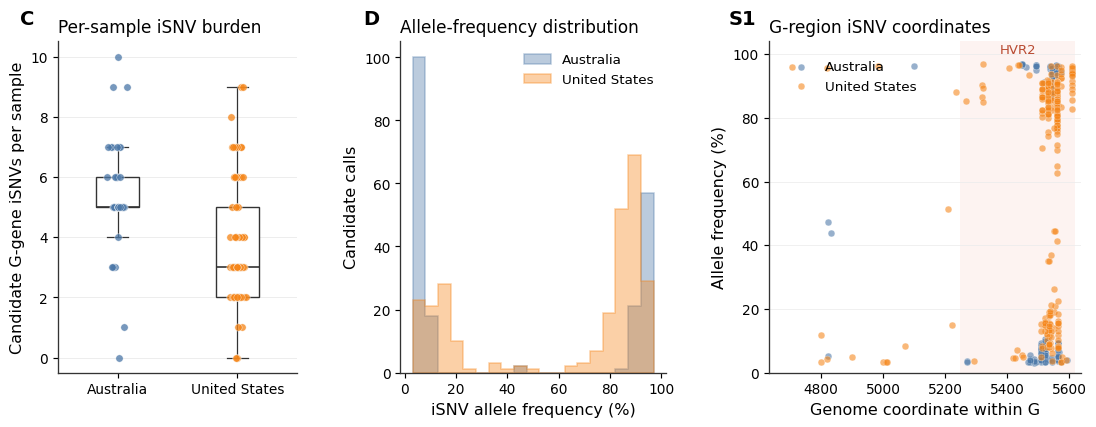

In [5]:
fig, paths = au.draw_g_isnv_summary(calls, counts, FIG_DIR)
display(paths)
plt.show()
